## Introduction on how to use the simulation

In [1]:
# Imports and loading of NEURON dll
import numpy as np
from neuron import h
import simulation as sim
import matplotlib.pyplot as plt
import helperFuncs as hf

## Example of running a full simulated electrical stimulation experiment

### Setting up the simulated cell

In [2]:
# clear all NEURON sims. Required if you are going to be running many exps
#  in Jupyter notebooks.
for sec in h.allsec():
   h.delete_section(sec=sec)

In [3]:
# Code to setup a single simulated RGC
RGC = sim.Local_Cell()
filename = 'cell_param_files/params_35_v2.csv'
RGC.build_cell(filename, 'mammalian_spike_35')

After any change to cell geometry or nseg, be sure to invoke setpointers()


In [5]:
# print out where the center of the soma is located and shift if needed
#  Note, behind the scenes this is shifting all simualted compartments by 
#  the necessary x,y,z transforms to get the cell to the right spot 
print('Current soma center is located at: ', RGC.soma_center)
RGC.shift_cell_x_y_z(0,0,0)
print('New soma center is located at: ', RGC.soma_center)

Current soma center is located at:  [-11.9399995803833, 0.0, 10.0]
New soma center is located at:  [0.0, 0.0, 0.0]


### Setting up the multielectrode electrical stimulus 

In [33]:
### Most features of the stimulus are set up a struct (dict) called Stim 
Stim = {}

# temporal features of the sitmulus 
Stim['pulseShape'] = 'triphasic'
Stim['dt'] = .005 # units: [ms]
Stim['delay'] = 10 # units: [ms]
Stim['dur'] = 0.05 # units: [ms]
Stim['stop'] = 80 # units: [ms]
Stim['amp'] = [-1,-1.5,-0.5] # units: [uA]

# calibration phase of the stimulus 
Stim['initDur'] = 50 # units: [ms]
Stim['initDt'] = 1 # units: [ms]
Stim['vInit'] = -70 # units: [mV] #TODO: Old is -70

# spatial features of the stimulus 
# --> specifically defining the electrode geometry 
Stim['electrodes'] = [[-1030,15,42],[-1015,-15,42],[-1000,15,42]] #[[-1030,15,42]]#
Stim['electrode_type'] = 'disk'
Stim['rhoExt'] = 1000 # Ohm*cm
Stim['elecDiam'] = 15 # um 15
Stim['polarity'] = -1 # anodic == 1; cathodic == -1 

Stim['pulseRatioTri'] = [-2/3,1,-1/3]
Stim['pulseRatioBi'] = [1,-1]
Stim['frequency'] = 10 # units: [Hz]

In [34]:
# have to set transfer impedances ANY TIME stimulus parameters are changed!! 
# Stim['electrodes'] = [[-1000,0,49]] # electrode location
hf.setupTransferImpedance_v2(Stim, RGC)

In [35]:
# Run single trial
# Play the stimulus into the cell, setting it up for stimulation
tsvec, isvec = hf.setupStimulus_unit(Stim)
isvec.play(h._ref_is_xtra, tsvec, 1) 

# set up recording vectors at every axonal segment 
vRec = []
for seg in RGC.axon:
    vRec.append(h.Vector().record(RGC.axon(seg.x)._ref_v))

# set up recoring vector for time in the simulation 
t_vec = h.Vector().record(h._ref_t)

# Initialization phase of the simulation 
h.init()
h.tstop = Stim['initDur']
h.dt = Stim['initDt']
h.finitialize(Stim['vInit'])
h.continuerun(h.tstop)

# Run the simulation 
h.tstop = Stim['initDur'] + Stim['stop']
h.steps_per_ms = int(1/Stim['dt'])
h.dt = Stim['dt']
h.continuerun(h.tstop)
print('***** sim done *****')

***** sim done *****


In [36]:
# Output steady state resting membrane voltages
print(vRec[0][int(Stim['initDur']/Stim['initDt'])])
print(vRec[0][int(Stim['initDur']/Stim['initDt']+ 5/Stim['dt'])])
print(vRec[0][int(Stim['initDur']/Stim['initDt']+ 10/Stim['dt'])])


-68.81577900005229
-68.80958880853888
-68.80550765383488


### Plot just one spike

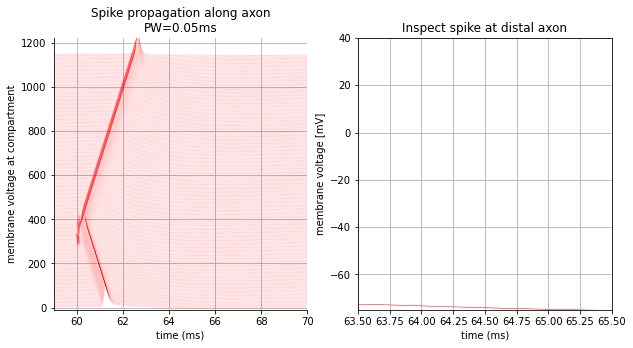

In [37]:
# Example of plotting voltage traces at all axonal segments, tracking spike
#  propagation along the membrane, expanding across space
fig, (ax,ax2) = plt.subplots(1,2,figsize=(10,5))
ax.grid()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

offset = -1*-70
offset_step = 2
for i in range(576):
    ax.plot(t_vec,vRec[i]+offset,'r',linewidth=0.1, alpha=0.5)

    offset += offset_step

dur = Stim['dur']
ax.set_title(f'Spike propagation along axon\nPW={dur}ms')
ax.set_xlabel('time (ms)')
ax.set_ylabel('membrane voltage at compartment')

ax.set_xlim(59,70)
ax.set_ylim(-10,int(576)*offset_step+70)

## Now, plot the spike just at the distal axon, noting timing difference
ax2.plot(t_vec,vRec[-1],'r',linewidth=0.5)

ax2.set_title('Inspect spike at distal axon')
ax2.set_xlabel('time (ms)')
ax2.set_ylabel('membrane voltage [mV]')

ax2.grid()
ax2.set_xlim(63.5,65.5)
ax2.set_ylim(-75,40)

plt.show()

### Run threshold finding code

In [17]:
# Here, vRec is the voltage along the axon
thr_c, t_vec, vRec_cathodic = hf.lowerThreshold_v2(Stim, RGC, lower=0, upper=5, num=25, epsilon=0.02)

Testing current:  [-0.0]
Testing current:  [-0.15535269687227293]
Testing current:  [-0.33483985417003437]
Testing current:  [-0.5422108254079407]
Testing current:  [-0.7817974362806785]
Testing current:  [-1.0586044732869841]
Testing current:  [-1.378414230005442]
Testing current:  [-1.7479072949161787]
Testing current:  [-2.174802103936399]
Testing current:  [-2.668016172818685]
Starting trial with 2.421409138377542 upper bound = 2.668016172818685 lower bound = 2.174802103936399
Starting trial with 2.298105621156971 upper bound = 2.421409138377542 lower bound = 2.174802103936399
Starting trial with 2.3597573797672564 upper bound = 2.421409138377542 lower bound = 2.298105621156971
Starting trial with 2.3289315004621134 upper bound = 2.3597573797672564 lower bound = 2.298105621156971
Starting trial with 2.313518560809542 upper bound = 2.3289315004621134 lower bound = 2.298105621156971
Lower threshold found at:  2.3289315004621134  uA


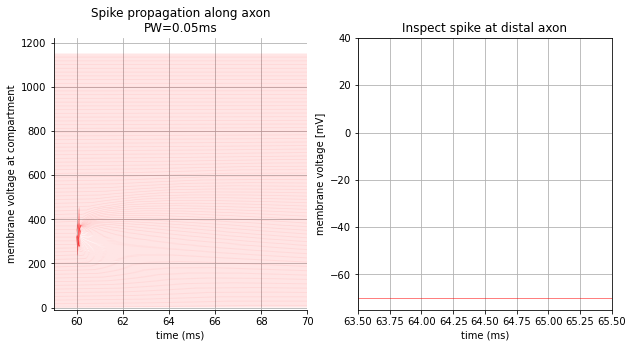

In [11]:
# Example of plotting voltage traces at all axonal segments, tracking spike
#  propagation along the membrane, expanding across space
fig, (ax,ax2) = plt.subplots(1,2,figsize=(10,5))
ax.grid()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

offset = -1*-70
offset_step = 2
for i in range(576):
    ax.plot(t_vec,vRec_cathodic[i]+offset,'r',linewidth=0.1, alpha=0.5)

    offset += offset_step

dur = Stim['dur']
ax.set_title(f'Spike propagation along axon\nPW={dur}ms')
ax.set_xlabel('time (ms)')
ax.set_ylabel('membrane voltage at compartment')

ax.set_xlim(59,70)
ax.set_ylim(-10,int(576)*offset_step+70)

## Now, plot the spike just at the distal axon, noting timing difference
ax2.plot(t_vec,vRec_cathodic[-1],'r',linewidth=0.5)

ax2.set_title('Inspect spike at distal axon')
ax2.set_xlabel('time (ms)')
ax2.set_ylabel('membrane voltage [mV]')

ax2.grid()
ax2.set_xlim(63.5,65.5)
ax2.set_ylim(-75,40)

plt.show()

In [ ]:
Stim['polarity'] = 1 # anodic == 1; cathodic == -1 

# Here, vRec is the voltage along the axon
thr_a, t_vec, vRec_anodic = hf.lowerThreshold(Stim, RGC, lower=0, upper=5, num=25, epsilon=0.02)

In [ ]:
print(len(vRec_anodic))